In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import pandas as pd
import numpy as np
from multiprocessing import Pool, cpu_count
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models
import tensorflow as tf
import matplotlib.cm as cm
import matplotlib.cm as cm_plt
import warnings
warnings.filterwarnings("ignore")
os.environ["TF_DISABLE_LAYOUT_OPTIMIZER"] = "1"

['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'MildDemented']


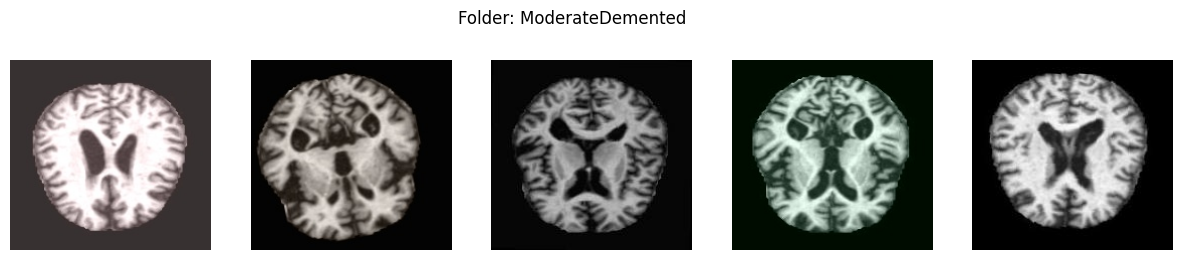

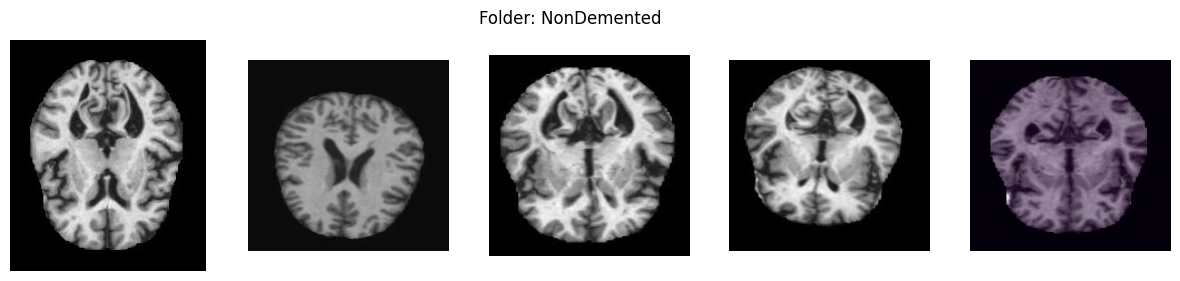

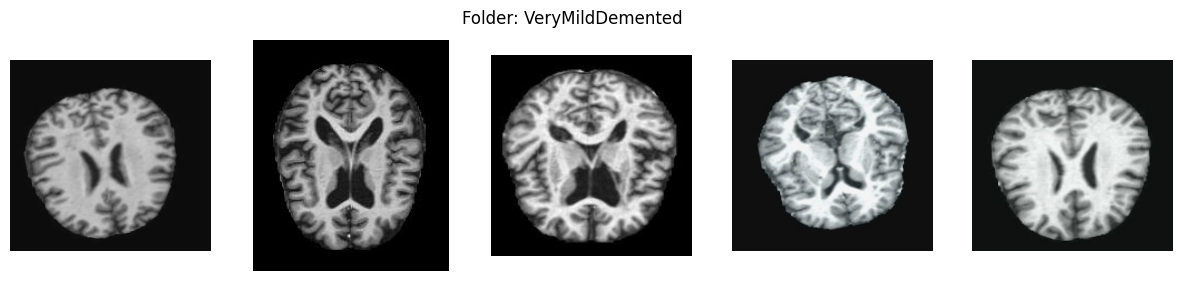

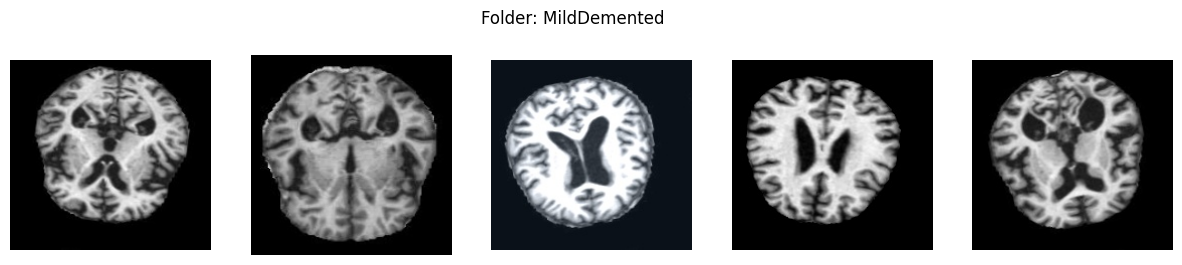

In [3]:
working_directory = "//kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images"
img_folders = os.listdir(working_directory)
print(img_folders)

for folder in img_folders:
    target_dir = os.path.join(working_directory, folder)
    five_images = os.listdir(target_dir)[:5]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))  

    for ax, path in zip(axes, five_images):
        img_path = os.path.join(target_dir, path)
        img = Image.open(img_path).convert('RGB') 
        ax.imshow(img)
        ax.axis('off')

    plt.suptitle(f"Folder: {folder}")
    plt.show()

In [4]:
data = []
for folder_name in os.listdir(working_directory):
    folder_path = os.path.join(working_directory, folder_name)
    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            data.append({
                'FilePath': os.path.join(folder_path, img_name),
                'Label': folder_name
            })

df = pd.DataFrame(data)
print(f"Total images found and stored in the DataFrame: {len(df)}")
df.head()

Total images found and stored in the DataFrame: 44000


,FilePath,Label
0,//kaggle/input/datasets/aryansinghal10/alzheim...,ModerateDemented
1,//kaggle/input/datasets/aryansinghal10/alzheim...,ModerateDemented
2,//kaggle/input/datasets/aryansinghal10/alzheim...,ModerateDemented
3,//kaggle/input/datasets/aryansinghal10/alzheim...,ModerateDemented
4,//kaggle/input/datasets/aryansinghal10/alzheim...,ModerateDemented


In [5]:
def read_image_metadata(path):
    try:
        with Image.open(path) as img:
            return [img.size[0], img.size[1], img.size, img.mode, len(img.getbands())]
    except:
        return [None, None, None, None, None]

def collect_image_metadata(df):
    num_cores = cpu_count()
    print(f"Launching {num_cores} parallel workers...")
    
    with Pool(num_cores) as pool:
        results = list(tqdm(pool.imap(read_image_metadata, df['FilePath']), 
                           total=len(df), 
                           desc="Multiprocessing Extraction"))
    
    meta_columns = ['Width', 'Height', 'Size', 'Mode', 'Channels']
    meta_df = pd.DataFrame(results, columns=meta_columns)
    
    return pd.concat([df.reset_index(drop=True), meta_df], axis=1)

df = collect_image_metadata(df)

Launching 4 parallel workers...


Multiprocessing Extraction: 100%|██████████| 44000/44000 [01:20<00:00, 547.00it/s]


In [7]:
print(f"Number of Images that failed to process: {df['Width'].isnull().sum()} images")

print("\nDistribution of Image Sizes")
df['Size'].value_counts().reset_index()

Number of Images that failed to process: 0 images

Distribution of Image Sizes


,Size,count
0,"(200, 190)",31107
1,"(180, 180)",6447
2,"(176, 208)",6446


In [8]:
# Bias Audit of Size and their Labels
df.groupby(['Size', 'Label']).size().unstack()

Label,MildDemented,ModerateDemented,NonDemented,VeryMildDemented
Size,,,,
"(176, 208)",911,95,3200,2240
"(180, 180)",913,94,3200,2240
"(200, 190)",8176,9811,6400,6720


In [9]:
print("\nDistribution of Image Modes/Channels")
df['Mode'].value_counts().reset_index()


Distribution of Image Modes/Channels


,Mode,count
0,RGB,33984
1,L,10016


In [10]:
train_val_df, test_df = train_test_split(
    df, 
    test_size=0.10, 
    stratify=df['Label'],
    random_state=42  
)

train_df, val_df = train_test_split(
    train_val_df, 
    test_size=0.1111, 
    stratify=train_val_df['Label'], 
    random_state=42
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 35200 | Val: 4400 | Test: 4400



TRAIN DISTRIBUTION

Label
NonDemented         29.090909
VeryMildDemented    25.454545
MildDemented        22.727273
ModerateDemented    22.727273
Name: proportion, dtype: float64


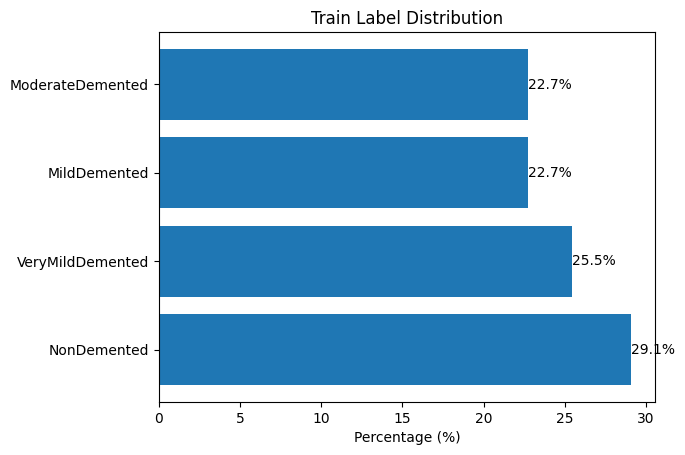

________________________________________________________________________________________________________________________

VALIDATION DISTRIBUTION

Label
NonDemented         29.090909
VeryMildDemented    25.454545
ModerateDemented    22.727273
MildDemented        22.727273
Name: proportion, dtype: float64


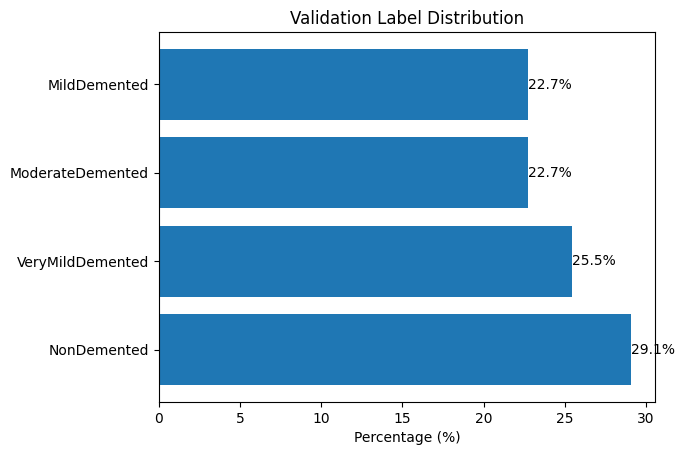

________________________________________________________________________________________________________________________

TEST DISTRIBUTION

Label
NonDemented         29.090909
VeryMildDemented    25.454545
ModerateDemented    22.727273
MildDemented        22.727273
Name: proportion, dtype: float64


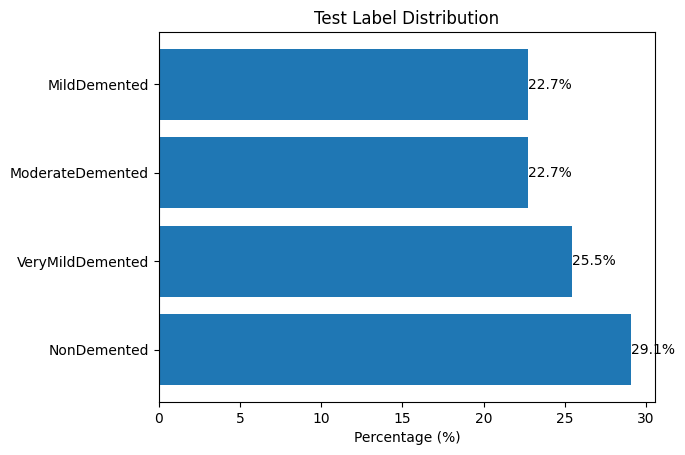

________________________________________________________________________________________________________________________


In [11]:
def check_ratios(dfs, names):
    
    for df, name in zip(dfs, names):
        print(f"\n{name} Distribution\n".upper())

        percentages = df["Label"].value_counts(normalize=True) * 100
        print(percentages)

        
        fig, ax = plt.subplots()
        ax.barh(
            percentages.index.astype(str),
            percentages.values
        )
        ax.set_xlabel("Percentage (%)")
        ax.set_title(f"{name} Label Distribution")

        ax.bar_label(
            ax.containers[0],
            fmt="%.1f%%"
        )

        plt.show()
        print("____" * 30)
        

check_ratios([train_df, val_df, test_df],["Train", "Validation", "Test"])

In [12]:
label_map = {
    'NonDemented': 0,
    'VeryMildDemented': 1,
    'MildDemented': 2,
    'ModerateDemented': 3
}

train_df['LabelNum'] = train_df['Label'].map(label_map)
val_df['LabelNum'] = val_df['Label'].map(label_map)
test_df['LabelNum'] = test_df['Label'].map(label_map)

In [13]:
BATCH_SIZE = 32
# IMG_SIZE = (224, 224)

def load_and_preprocess(path, label):
    # Read Image
    img = tf.io.read_file(path)
    # Force any image mode to RGB Mode/Channel
    img = tf.image.decode_jpeg(img, channels=3)
    # Resize and Pad
    img = tf.image.resize_with_pad(img, 224, 224)
    img = tf.cast(img, tf.float32) 
    return img, label


def create_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['FilePath'].values, dataframe['LabelNum'].values))
    # Using all CPU cores
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    # Batch and prefetch to keep the GPU busy
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# Creating the stream for all Splits
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

I0000 00:00:1776997988.164216      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776997988.169932      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [14]:
def build_model(num_classes=4):
    inputs = tf.keras.Input(shape=(224, 224, 3))

    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
    )
    base.trainable = False

    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs)

# Initializing our Model
model = build_model(num_classes=4)

# Compiling our model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [15]:
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices: {strategy.num_replicas_in_sync}")

with strategy.scope():
    model = build_model(num_classes=4)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    # Lower the learning rate if we get 'stuck' on a plateau
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3),
    # Save the best version of our model automatically
    tf.keras.callbacks.ModelCheckpoint('alzheimer_model.keras', save_best_only=True)
]

# Launching the training with 40 Epochs
EPOCHS = 40

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks 
)

Epoch 1/40
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 70s 63ms/step - accuracy: 0.7297 - loss: 0.6195 - val_accuracy: 0.8327 - val_loss: 0.4129 - learning_rate: 0.0010
Epoch 2/40
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 69s 62ms/step - accuracy: 0.7524 - loss: 0.5734 - val_accuracy: 0.8486 - val_loss: 0.3732 - learning_rate: 0.0010
Epoch 3/40
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 69s 62ms/step - accuracy: 0.7678 - loss: 0.5423 - val_accuracy: 0.8641 - val_loss: 0.3324 - learning_rate: 0.0010
Epoch 4/40
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 69s 62ms/step - accuracy: 0.7829 - loss: 0.5170 - val_accuracy: 0.8752 - val_loss: 0.3096 - learning_rate: 0.0010
Epoch 5/40
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 69s 62ms/step - accuracy: 0.7910 - loss: 0.4902 - val_accuracy: 0.8766 - val_loss: 0.3050 - learning_rate: 0.0010
Epoch 6/40
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 69s 62ms/step - accuracy: 0.8073 - loss: 0.4582 - val_accuracy: 0.8891 - val_loss: 0.2701 - learning_rate: 0.0010
Epoch 7/40
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 70s 62ms/step - accura

In [24]:
# =========================
# LOAD MODEL IN KERAS FORMAT
# =========================

import tensorflow as tf

model = tf.keras.models.load_model(
    "/kaggle/input/models/ahmedmoatasem1/model/keras/default/1/alzheimer_model.keras"
)

print("Model loaded successfully")
model.summary()

Model loaded successfully


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,046,705 (19.25 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 663,050 (2.53 MB)

In [25]:
# Evaluate EfficientNet on Test Set

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

test_acc = np.mean(y_pred == y_true)

print(f"Test Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(label_map.keys())
))

I0000 00:00:1776998533.039463     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step
Test Accuracy: 96.61%

                  precision    recall  f1-score   support

     NonDemented       0.95      0.95      0.95      1280
VeryMildDemented       0.95      0.94      0.94      1120
    MildDemented       0.98      0.99      0.98      1000
ModerateDemented       1.00      1.00      1.00      1000

        accuracy                           0.97      4400
       macro avg       0.97      0.97      0.97      4400
    weighted avg       0.97      0.97      0.97      4400



138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step


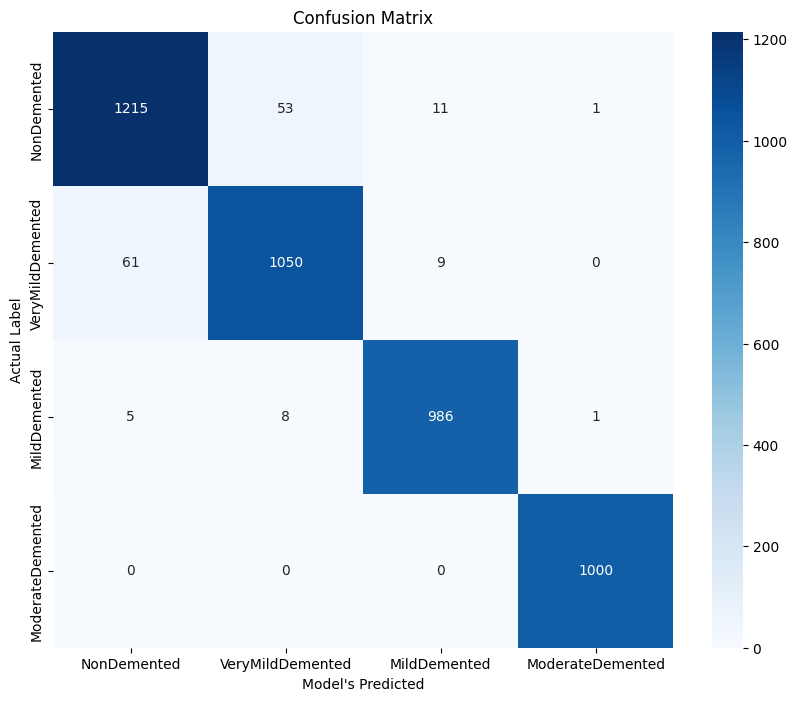

                  precision    recall  f1-score   support

     NonDemented       0.95      0.95      0.95      1280
VeryMildDemented       0.95      0.94      0.94      1120
    MildDemented       0.98      0.99      0.98      1000
ModerateDemented       1.00      1.00      1.00      1000

        accuracy                           0.97      4400
       macro avg       0.97      0.97      0.97      4400
    weighted avg       0.97      0.97      0.97      4400



In [26]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1) 

y_true = np.concatenate([y for x, y in test_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_map.keys(), 
            yticklabels=label_map.keys())
plt.xlabel("Model's Predicted")
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=label_map.keys()))

In [28]:

# ── Collect one test image per class ──────────────────────────────────────
class_names = list(label_map.keys())   # order matches label_map
n_classes   = len(class_names)

xai_images = {}   # {class_idx: np.array [H,W,C]  float32  0-1}
xai_labels = {}   # {class_idx: int}

for batch_imgs, batch_lbls in test_ds:
    for img, lbl in zip(batch_imgs.numpy(), batch_lbls.numpy()):
        idx = int(lbl)
        if idx not in xai_images:
            xai_images[idx] = img          # float32, shape (H,W,C)
            xai_labels[idx] = idx
        if len(xai_images) == n_classes:
            break
    if len(xai_images) == n_classes:
        break

print(f"Collected {len(xai_images)} images — one per class:")
for idx, name in enumerate(class_names):
    img = xai_images[idx]
    print(f"  [{idx}] {name}  shape={img.shape}  "
          f"dtype={img.dtype}  min={img.min():.3f}  max={img.max():.3f}")

Collected 4 images — one per class:
  [0] NonDemented  shape=(224, 224, 3)  dtype=float32  min=0.000  max=232.441
  [1] VeryMildDemented  shape=(224, 224, 3)  dtype=float32  min=0.000  max=255.000
  [2] MildDemented  shape=(224, 224, 3)  dtype=float32  min=0.000  max=205.649
  [3] ModerateDemented  shape=(224, 224, 3)  dtype=float32  min=0.000  max=204.640


Using layer: top_conv


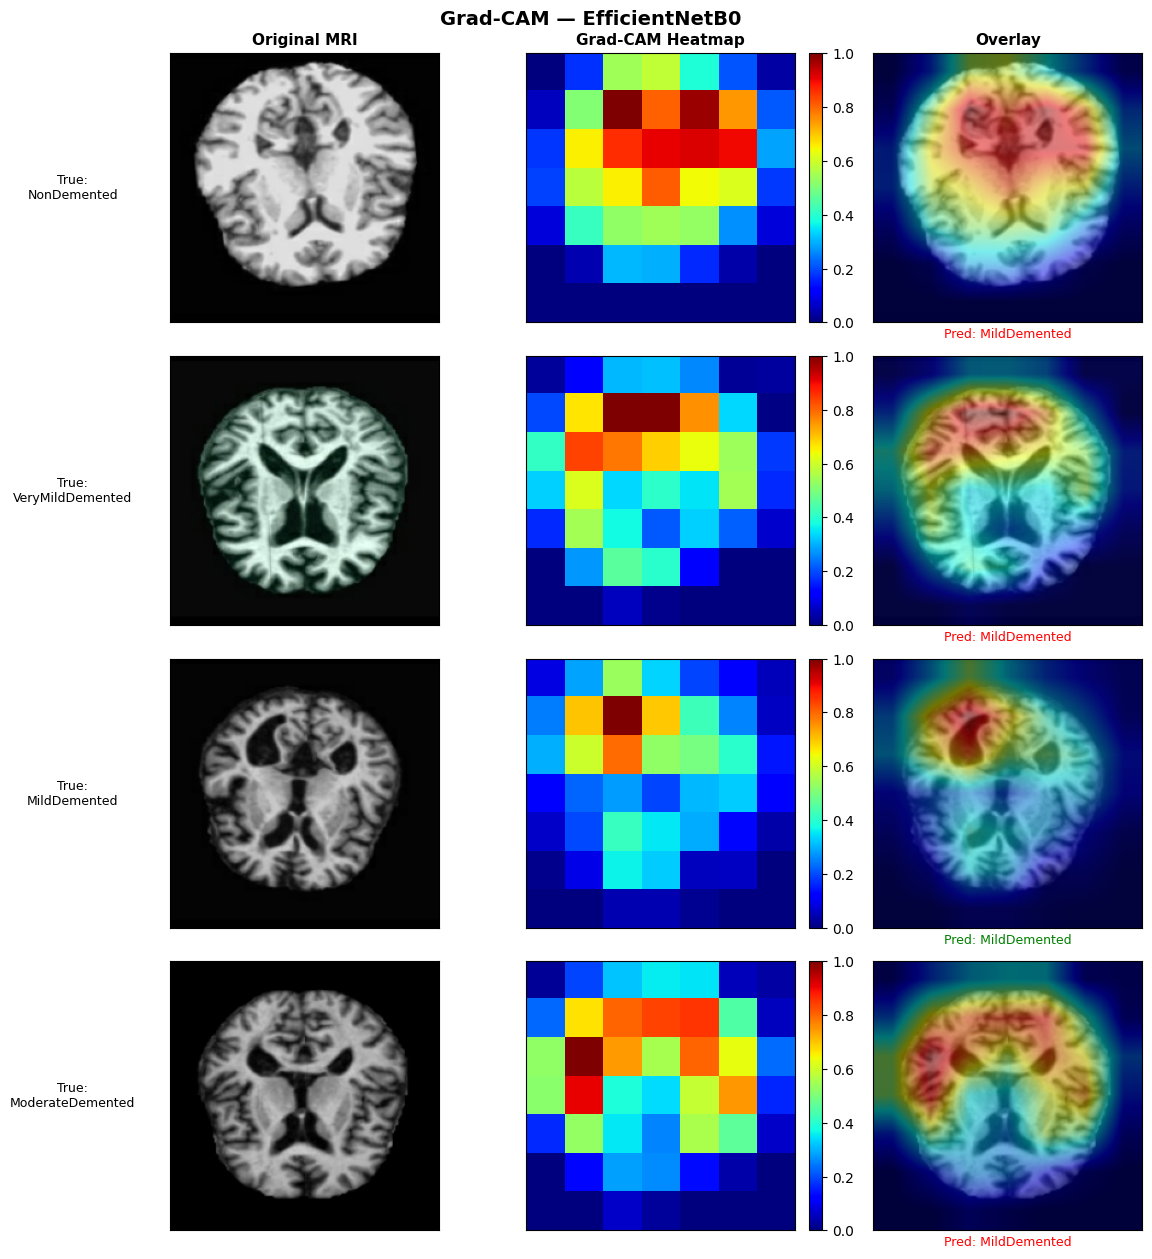

In [47]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

base_model = model.get_layer("efficientnetb0")
last_conv_layer_name = "top_conv"

grad_base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3)
)
grad_base.set_weights(base_model.get_weights())
grad_base.trainable = False

gap_layer = model.get_layer("global_average_pooling2d_1")
bn_layer = model.get_layer("batch_normalization_1")
drop_layer = model.get_layer("dropout_1")
dense1_layer = model.get_layer("dense_2")
dense2_layer = model.get_layer("dense_3")

conv_model = tf.keras.Model(
    inputs=grad_base.input,
    outputs=grad_base.get_layer(last_conv_layer_name).output
)

print("Using layer:", last_conv_layer_name)

def make_gradcam_heatmap(img_array):
    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)

        x = gap_layer(conv_outputs)
        x = bn_layer(x, training=False)
        x = drop_layer(x, training=False)
        x = dense1_layer(x)

        # normal prediction
        probs = dense2_layer(x)
        pred_index = tf.argmax(probs[0])

        # IMPORTANT: use pre-softmax logits manually
        kernel, bias = dense2_layer.weights
        logits = tf.matmul(x, kernel) + bias
        class_score = logits[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_outputs[0] * pooled_grads, axis=-1)

    heatmap = heatmap.numpy()
    heatmap = np.maximum(heatmap, 0)

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    return heatmap, int(pred_index.numpy())


def apply_heatmap_overlay(img_np, heatmap, alpha=0.45):
    h, w = img_np.shape[:2]

    hmap = cv2.resize(heatmap, (w, h))
    hmap = np.uint8(255 * hmap)

    hmap = cv2.applyColorMap(hmap, cv2.COLORMAP_JET)
    hmap = cv2.cvtColor(hmap, cv2.COLOR_BGR2RGB)

    base = np.uint8(img_np * 255) if img_np.max() <= 1.0 else np.uint8(img_np)

    overlay = cv2.addWeighted(base, 1 - alpha, hmap, alpha, 0)
    return overlay


fig, axes = plt.subplots(n_classes, 3, figsize=(12, n_classes * 3.2))
fig.suptitle("Grad-CAM — EfficientNetB0", fontsize=14, fontweight="bold")

for col, title in enumerate(["Original MRI", "Grad-CAM Heatmap", "Overlay"]):
    axes[0][col].set_title(title, fontsize=11, fontweight="bold")

for row, class_idx in enumerate(range(n_classes)):
    img = xai_images[class_idx]
    inp = tf.expand_dims(tf.cast(img, tf.float32), 0)

    hmap, pred_idx = make_gradcam_heatmap(inp)
    overlay = apply_heatmap_overlay(img, hmap)

    disp = np.uint8(img * 255) if img.max() <= 1.0 else np.uint8(img)

    axes[row][0].imshow(disp)
    axes[row][0].set_ylabel(
        f"True:\n{class_names[class_idx]}",
        fontsize=9,
        rotation=0,
        labelpad=70,
        va="center"
    )

    im = axes[row][1].imshow(hmap, cmap="jet")
    plt.colorbar(im, ax=axes[row][1], fraction=0.046, pad=0.04)

    axes[row][2].imshow(overlay)
    axes[row][2].set_xlabel(
        f"Pred: {class_names[pred_idx]}",
        fontsize=9,
        color="green" if pred_idx == class_idx else "red"
    )

    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("/kaggle/working/xai_gradcam_fixed_logits.png", dpi=150, bbox_inches="tight")
plt.show()

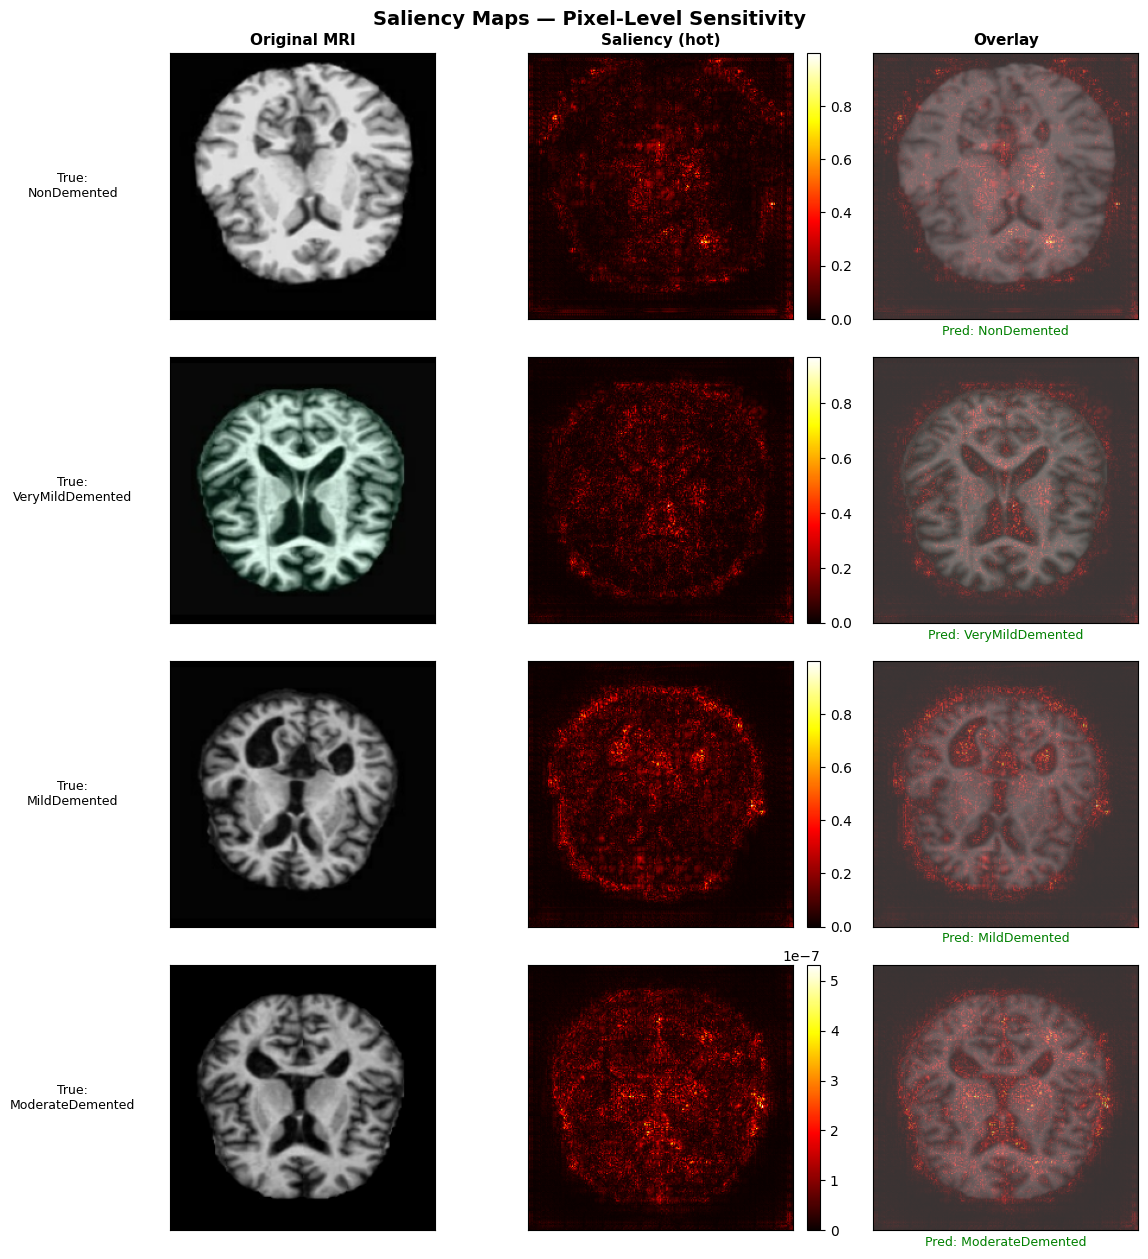

Saliency maps saved → /kaggle/working/xai_saliency.png


In [28]:
def compute_saliency(model, img_np):
    """img_np: (H,W,C) float32.  Returns saliency (H,W) normalized 0-1, pred_idx."""
    img_var = tf.Variable(tf.expand_dims(tf.cast(img_np, tf.float32), 0))
    with tf.GradientTape() as tape:
        tape.watch(img_var)
        preds     = model(img_var)
        top_class = tf.argmax(preds[0])
        score     = preds[:, top_class]
    grads    = tape.gradient(score, img_var)[0].numpy()   # (H,W,C)
    saliency = np.max(np.abs(grads), axis=-1)             # (H,W)
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency, int(top_class.numpy())


fig, axes = plt.subplots(n_classes, 3, figsize=(12, n_classes * 3.2))
fig.suptitle('Saliency Maps — Pixel-Level Sensitivity', fontsize=14, fontweight='bold')
for col, title in enumerate(['Original MRI', 'Saliency (hot)', 'Overlay']):
    axes[0][col].set_title(title, fontsize=11, fontweight='bold')

for row, class_idx in enumerate(range(n_classes)):
    img      = xai_images[class_idx]
    sal, pred_idx = compute_saliency(model, img)

    disp = np.uint8(img * 255) if img.max() <= 1.0 else np.uint8(img)

    axes[row][0].imshow(disp, cmap='gray')
    axes[row][0].set_ylabel(f'True:\n{class_names[class_idx]}', fontsize=9,
                             rotation=0, labelpad=70, va='center')

    im = axes[row][1].imshow(sal, cmap='hot')
    plt.colorbar(im, ax=axes[row][1], fraction=0.046, pad=0.04)

    # Overlay: grey base + hot saliency
    axes[row][2].imshow(disp, cmap='gray', alpha=0.55)
    axes[row][2].imshow(sal,  cmap='hot',  alpha=0.55)
    axes[row][2].set_xlabel(f'Pred: {class_names[pred_idx]}', fontsize=9,
                             color='green' if pred_idx==class_idx else 'red')

    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('/kaggle/working/xai_saliency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saliency maps saved → /kaggle/working/xai_saliency.png')

In [29]:
%pip install lime -q

Note: you may need to restart the kernel to use updated packages.


  LIME: explaining NonDemented...

  0%|          | 0/1000 [00:00<?, ?it/s]

 pred=NonDemented
  LIME: explaining VeryMildDemented...

  0%|          | 0/1000 [00:00<?, ?it/s]

 pred=VeryMildDemented
  LIME: explaining MildDemented...

  0%|          | 0/1000 [00:00<?, ?it/s]

 pred=MildDemented
  LIME: explaining ModerateDemented...

  0%|          | 0/1000 [00:00<?, ?it/s]

 pred=ModerateDemented


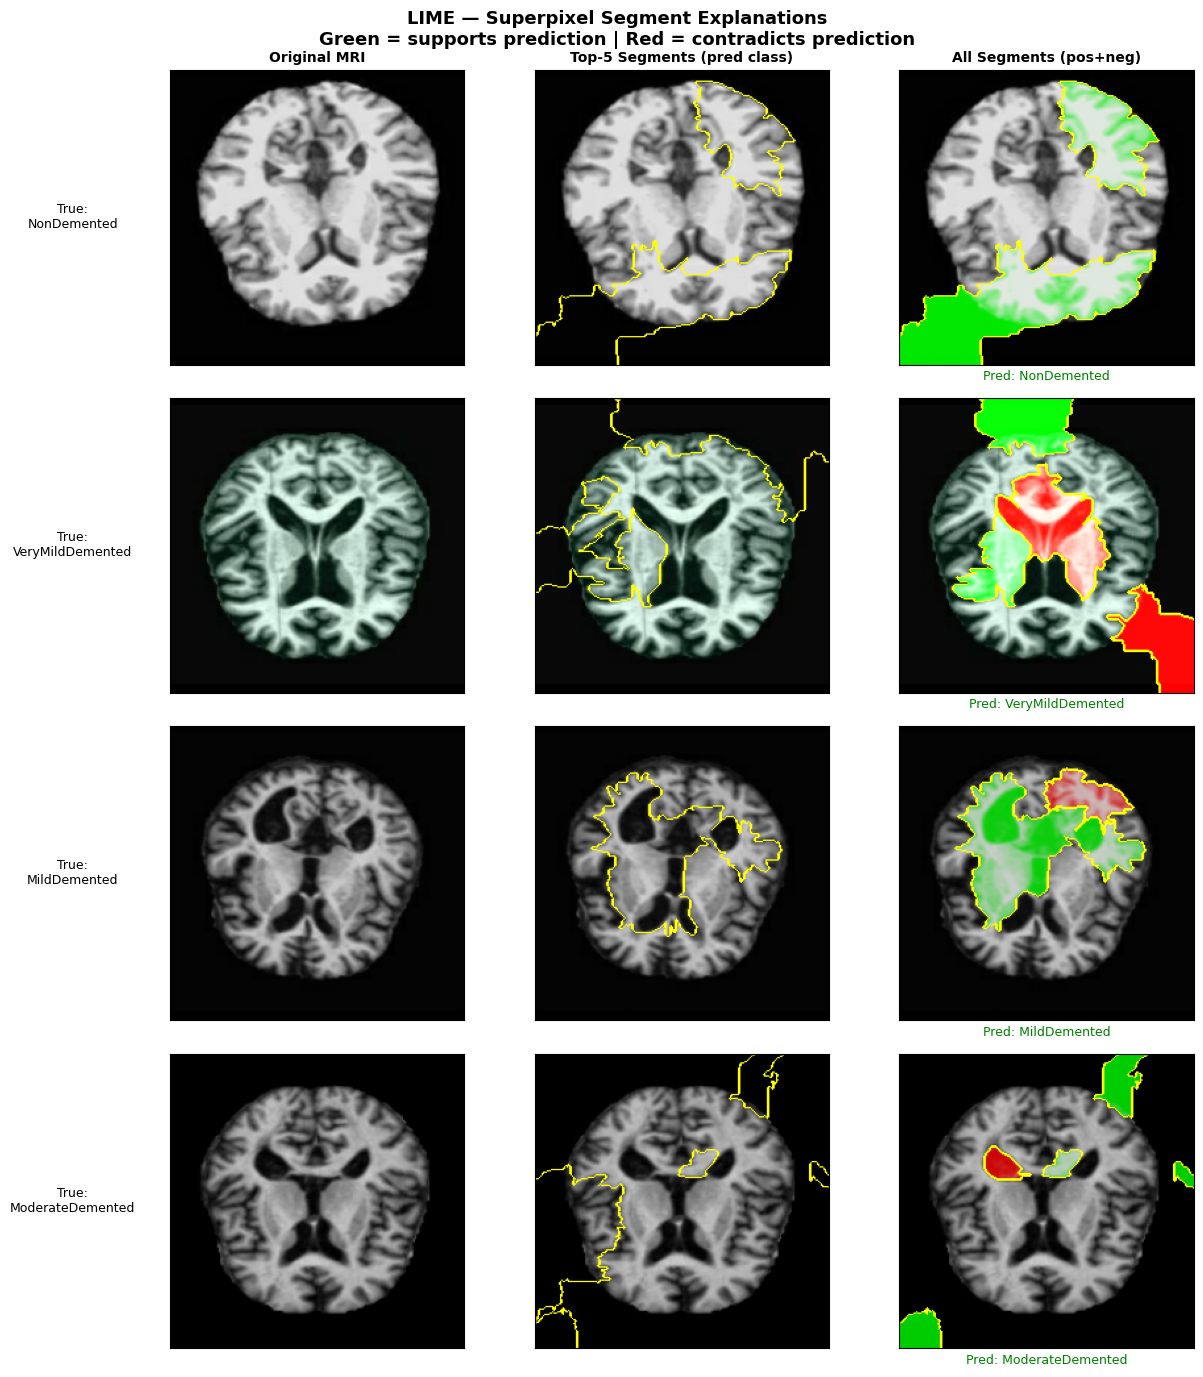

LIME saved → /kaggle/working/xai_lime.png


In [33]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

lime_explainer = lime_image.LimeImageExplainer()


def predict_fn_lime(images_uint8):
    """
    LIME passes uint8 numpy arrays (N, H, W, C).
    We cast to float32 and match whatever range the model expects.
    """
    imgs = tf.cast(images_uint8, tf.float32)
    # If your model was trained on 0-1 inputs, divide by 255:
    if xai_images[0].max() <= 1.0:
        imgs = imgs / 255.0
    return model.predict(imgs, verbose=0)


fig, axes = plt.subplots(n_classes, 3, figsize=(13, n_classes * 3.5))
fig.suptitle('LIME — Superpixel Segment Explanations\n'
             'Green = supports prediction | Red = contradicts prediction',
             fontsize=13, fontweight='bold')

for col, title in enumerate(['Original MRI', 'Top-5 Segments (pred class)', 'All Segments (pos+neg)']):
    axes[0][col].set_title(title, fontsize=10, fontweight='bold')

for row, class_idx in enumerate(range(n_classes)):
    img   = xai_images[class_idx]                           # float32 (H,W,C)
    img_u = np.uint8(img * 255) if img.max() <= 1.0 else np.uint8(img)
    if img_u.ndim == 2:
        img_u = np.stack([img_u]*3, axis=-1)
    if img_u.shape[2] == 1:
        img_u = np.concatenate([img_u]*3, axis=-1)

    print(f'  LIME: explaining {class_names[class_idx]}...', end='', flush=True)
    explanation = lime_explainer.explain_instance(
        img_u,
        predict_fn_lime,
        top_labels   = n_classes,
        hide_color   = 0,
        num_samples  = 1000,
    )
    pred_idx = int(np.argmax(model.predict(tf.expand_dims(
        tf.cast(img, tf.float32), 0), verbose=0)))
    print(f' pred={class_names[pred_idx]}')

    # col 0: original
    axes[row][0].imshow(img_u)
    axes[row][0].set_ylabel(f'True:\n{class_names[class_idx]}', fontsize=9,
                             rotation=0, labelpad=70, va='center')

    # col 1: top-5 positive segments only
    temp1, mask1 = explanation.get_image_and_mask(
        pred_idx, positive_only=True, num_features=5, hide_rest=False)
    axes[row][1].imshow(mark_boundaries(temp1 / 255.0, mask1))

    # col 2: positive + negative segments
    temp2, mask2 = explanation.get_image_and_mask(
        pred_idx, positive_only=False, num_features=5, hide_rest=False)
    axes[row][2].imshow(mark_boundaries(temp2 / 255.0, mask2))
    axes[row][2].set_xlabel(f'Pred: {class_names[pred_idx]}', fontsize=9,
                             color='green' if pred_idx==class_idx else 'red')

    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('/kaggle/working/xai_lime.png', dpi=150, bbox_inches='tight')
plt.show()
print('LIME saved → /kaggle/working/xai_lime.png')

In [34]:
%pip install shap -q

Note: you may need to restart the kernel to use updated packages.


In [35]:
import shap

# Use smaller background to avoid GPU/RAM issues
bg_list = []
for batch_imgs, _ in test_ds:
    for img in batch_imgs.numpy():
        bg_list.append(img)
        if len(bg_list) >= 20:
            break
    if len(bg_list) >= 20:
        break

background = np.stack(bg_list, axis=0).astype(np.float32)
test_array = np.stack([xai_images[i] for i in range(n_classes)], axis=0).astype(np.float32)

print("Background shape:", background.shape)
print("Test array shape:", test_array.shape)

print("Running SHAP GradientExplainer...")

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_array)

print("SHAP done.")

Background shape: (20, 224, 224, 3)
Test array shape: (4, 224, 224, 3)
Running SHAP GradientExplainer...
SHAP done.


In [39]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("List length:", len(shap_values))
    for i, sv in enumerate(shap_values):
        print(i, sv.shape)
else:
    print("Array shape:", shap_values.shape)

<class 'numpy.ndarray'>
Array shape: (4, 224, 224, 3, 4)


In [40]:
# =========================
# FIX SHAP VALUES SHAPE
# =========================

if isinstance(shap_values, list):
    # old format: list of 4 arrays, each = (N,H,W,C)
    shap_arr = np.stack(shap_values, axis=-1)   # (N,H,W,C,classes)
else:
    shap_arr = shap_values

print("Fixed SHAP array shape:", shap_arr.shape)

Fixed SHAP array shape: (4, 224, 224, 3, 4)


SHAP array shape: (4, 224, 224, 3, 4)


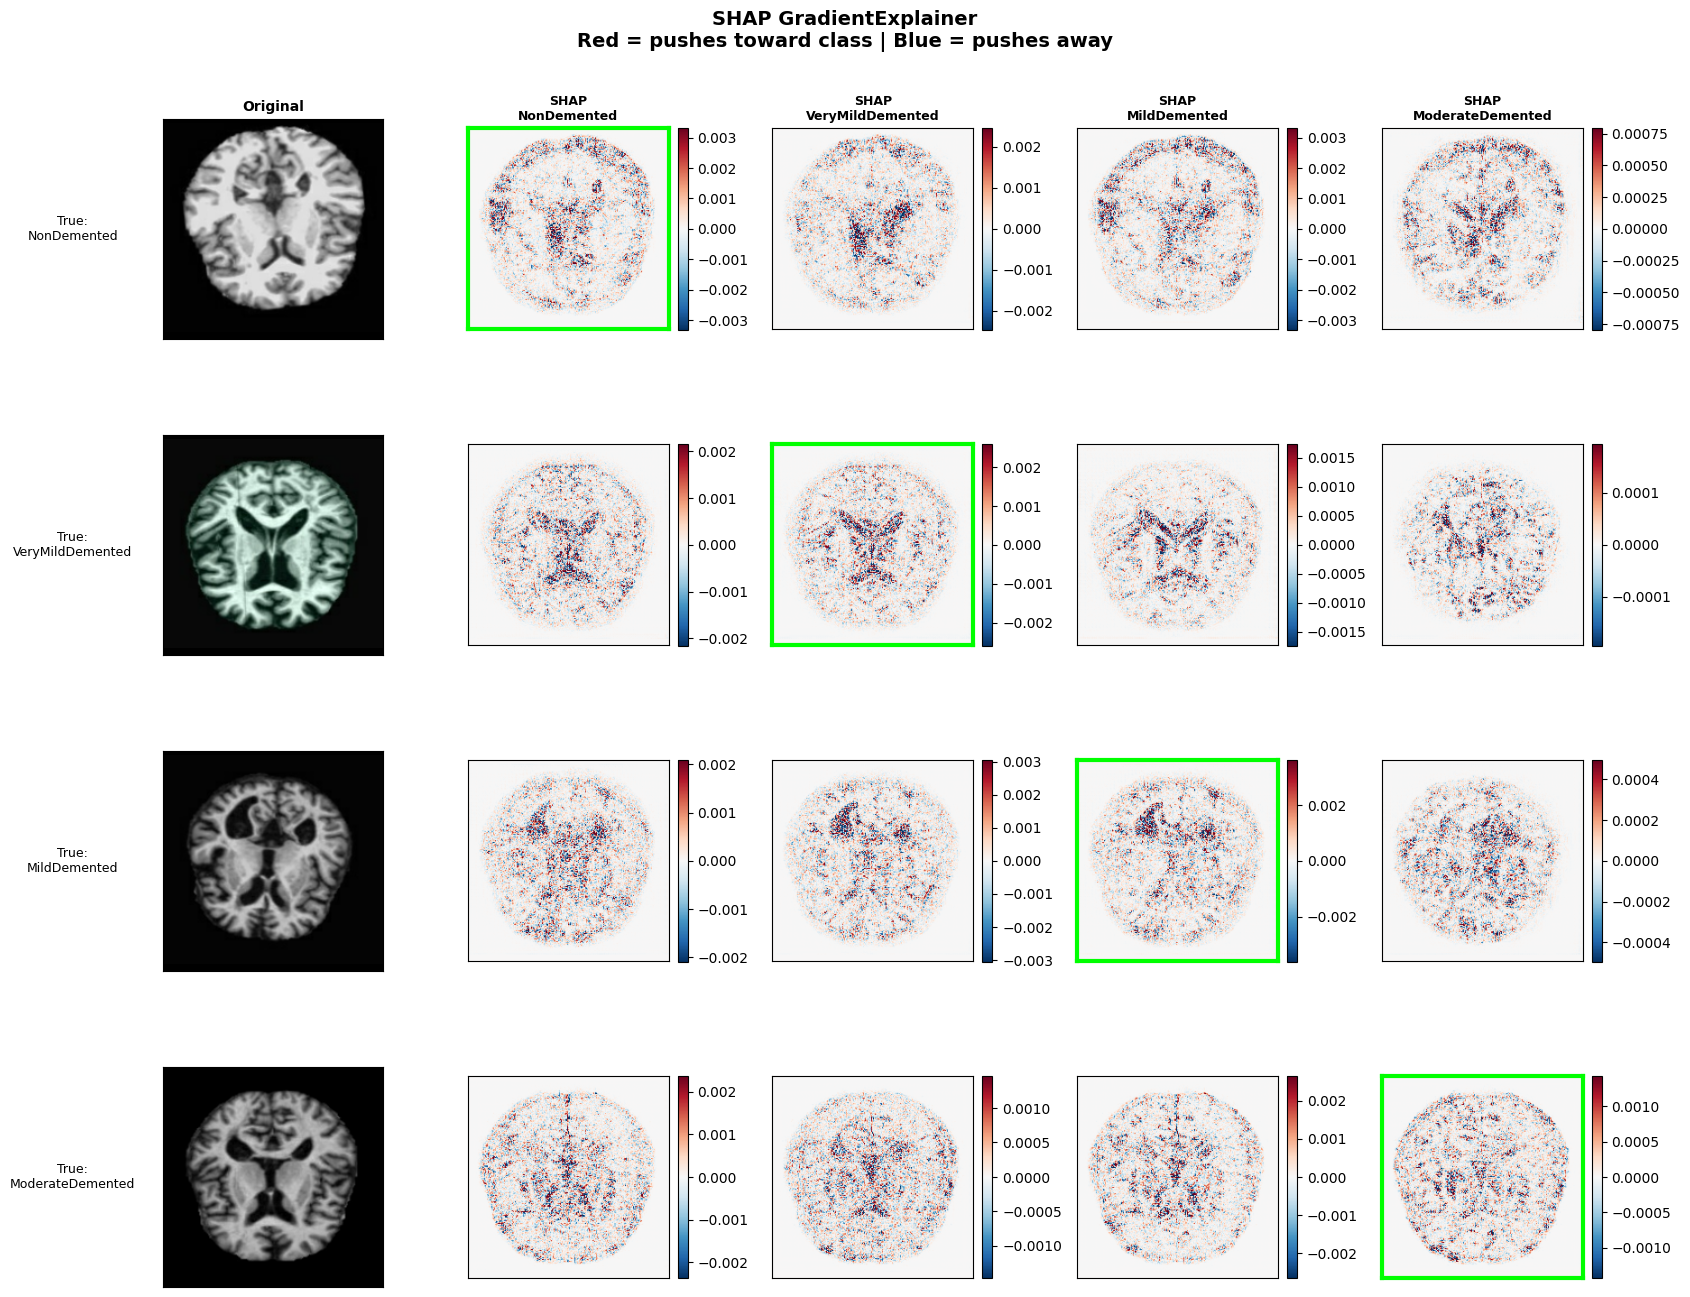

SHAP grid saved → /kaggle/working/xai_shap_grid_like_before.png


In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Fix SHAP shape
if isinstance(shap_values, list):
    shap_arr = np.stack(shap_values, axis=-1)   # (N,H,W,C,classes)
else:
    shap_arr = shap_values

print("SHAP array shape:", shap_arr.shape)

fig, axes = plt.subplots(
    n_classes,
    n_classes + 1,
    figsize=(3.4 * (n_classes + 1), 3.4 * n_classes)
)

fig.suptitle(
    "SHAP GradientExplainer\nRed = pushes toward class | Blue = pushes away",
    fontsize=14,
    fontweight="bold"
)

# Column titles
axes[0][0].set_title("Original", fontsize=10, fontweight="bold")
for col, cname in enumerate(class_names):
    axes[0][col + 1].set_title(f"SHAP\n{cname}", fontsize=9, fontweight="bold")

for row in range(n_classes):
    img = test_array[row]
    disp = np.uint8(img * 255) if img.max() <= 1.0 else np.uint8(img)

    pred_idx = int(np.argmax(model.predict(tf.expand_dims(img, 0), verbose=0)))

    # Original image
    axes[row][0].imshow(disp)
    axes[row][0].set_ylabel(
        f"True:\n{class_names[row]}",
        fontsize=9,
        rotation=0,
        labelpad=65,
        va="center"
    )
    axes[row][0].set_xticks([])
    axes[row][0].set_yticks([])

    # SHAP maps for each class
    for col in range(n_classes):
        sv = shap_arr[row, :, :, :, col]   # (224,224,3)

        # signed SHAP map
        sv_2d = np.mean(sv, axis=-1)

        # make values visible but keep red/blue meaning
        vmax = np.percentile(np.abs(sv_2d), 99)
        if vmax == 0:
            vmax = np.max(np.abs(sv_2d)) + 1e-8

        ax = axes[row][col + 1]

        im = ax.imshow(
            sv_2d,
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax
        )

        # green border around predicted class
        if col == pred_idx:
            for spine in ax.spines.values():
                spine.set_edgecolor("lime")
                spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("/kaggle/working/xai_shap_grid_like_before.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP grid saved → /kaggle/working/xai_shap_grid_like_before.png")